# Estimation of the AMOC tipping point

In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import seaborn as sns
from tqdm import tqdm
from scipy.stats import norm
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.stats import wasserstein_distance
from scipy.optimize import differential_evolution


## Baseline (article's reproduction)

I try to reproduce the results of the article using the pseudo-likelihood method (original code in R): https://erda.ku.dk/archives/afce4e1c3ac6f0db61c27cb45c2e9b14/AMOCestimationUPDATED.html#)

        time     AMOC0     AMOC1     AMOC2        GM
0  1870.0833  0.163951  0.255713  0.347475 -0.091762
1  1870.1667  0.313431  0.473210  0.632988 -0.159778
2  1870.2500  0.204185  0.278375  0.352565 -0.074190
3  1870.3333  0.141020  0.269190  0.397360 -0.128170
4  1870.4167  0.058445  0.276818  0.495190 -0.218373


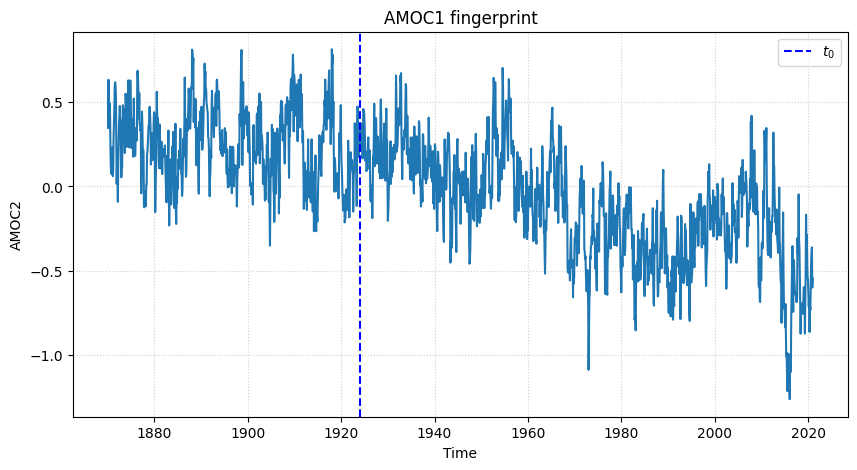

In [253]:
df = pd.read_csv('AMOC.txt', sep=' ')
print(df.head())
plt.figure(figsize=(10, 5))
plt.plot(df['time'], df['AMOC2'], linestyle='-') #AMOC2 is AMOC - 2*GM
plt.axvline(x=1924, color='blue', linestyle='--', label='$t_0$')
plt.title('AMOC1 fingerprint')
plt.xlabel('Time')
plt.ylabel('AMOC2')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

delta_t = 1/12 #time step (one point every month)

In [254]:
# Split data into stationary (t < t0) and non-stationary (t >= t0) regimes
t0 = 1924.0
df_stat = df[df['time'] < t0].copy()
df_nonstat = df[df['time'] >= t0].copy()


In [255]:
def loglikOU_fun(pars, data, delta):
    """Mirror of loglikOU.fun from R code"""
    alpha0 = max(pars[0], 0.001)
    mu0    = pars[1]
    sigma2 = max(0, pars[2]) 
    n      = len(data)
    
    Xupp   = data[1:]
    Xlow   = data[:-1]
    
    gamma2 = sigma2 / (2 * alpha0)
    rho0   = np.exp(-alpha0 * delta)
    
    m_part = Xupp - Xlow * rho0 - mu0 * (1 - rho0) #observation minus the mean of transition distribution
    v_part = gamma2 * (1 - rho0**2) # variance of transition distribution
    
    # 2 * negative log-likelihood configuration up to a constant
    loglik = - n * np.log(v_part) - np.sum(m_part**2 / v_part)
    return -loglik

def estimate_OU(data, delta, initial_values=None):
    """Mirror of estimate.OU from R code"""
    if initial_values is None:
        n    = len(data)
        Xupp = data[1:]
        Xlow = data[:-1]
        mu   = np.mean(data)
        
        # Guard log calculations from invalid numeric divisions
        num = np.sum((Xupp - mu) * (Xlow - mu))
        den = np.sum((Xlow - mu)**2)
        alpha = -np.log(max(0.001, num / den)) / delta
        
        s2 = np.mean(np.diff(data)**2) / delta
        par_init = [alpha, mu, s2]
    else:
        par_init = initial_values
        
    def minuslogl(pars):
        try:
            val = loglikOU_fun(pars, data, delta)
            return 10000 if np.isnan(val) else val
        except:
            return 10000
            
    # Nelder-Mead substitute for R's stats4::mle
    res = minimize(minuslogl, par_init, method='Nelder-Mead')
    return res.x

x_stat = df_stat['AMOC2'].values
alpha_est, mu_est, sigma2_est = estimate_OU(x_stat, delta_t)

print("--- Stage 1: Stationary OU Outputs ---")
print(f"Alpha:  {alpha_est:.4f}")
print(f"Mu:     {mu_est:.4f}")
print(f"Sigma2: {sigma2_est:.4f}\n")

--- Stage 1: Stationary OU Outputs ---
Alpha:  3.0592
Mu:     0.2474
Sigma2: 0.2962



In [256]:
def loglik_fun(pars, data, delta, alpha0, mu0, sigma20, pen=0.004):
    """Mirror of loglik.fun from R code"""
    tau     = pars[0]
    a       = max(0.1, pars[1])
    m       = mu0 - alpha0 / (2 * a)
    lambda0 = -(alpha0**2) / (4 * a)
    sigma2  = sigma20
    n       = len(data)
    
    Xupp    = data[1:]
    Xlow    = data[:-1]
    
    time_seq = delta * np.arange(1, n)
    lam_seq    = lambda0 * (1 - time_seq / tau)
    alpha_seq  = 2 * np.sqrt(-a * lam_seq)
    gamma2_seq = sigma2 / (2 * alpha_seq)
    rho_seq    = np.exp(-alpha_seq * delta)
    mu_seq     = m + np.sqrt(-lam_seq / a)
    
    # Calculating the Strang splitting scheme pseudo-likelihood
    fh_half_tmp    = a * delta * (Xlow - mu_seq) / 2
    fh_half_tmpupp = a * delta * (Xupp - mu_seq) / 2
    
    fh_half     = (mu_seq * fh_half_tmp + Xlow) / (fh_half_tmp + 1)
    fh_half_inv = (mu_seq * fh_half_tmpupp - Xupp) / (fh_half_tmpupp - 1)
    
    mu_h        = fh_half * rho_seq + mu_seq * (1 - rho_seq)
    m_part      = fh_half_inv - mu_h
    var_part    = gamma2_seq * (1 - rho_seq**2)
    
    det_Dfh_half_inv = 1 / (a * delta * (Xupp - mu_seq) / 2 - 1)**2
    
    # Check penalty application logic constraint matching a < 1
    pen_term = pen * n * (1/a - 1) if a < 1 else 0
    
    loglik = - np.sum(np.log(var_part)) - np.sum(m_part**2 / var_part) + \
              2 * np.sum(np.log(det_Dfh_half_inv)) - pen_term
              
    return -loglik

def estimate_tipping(data, delta, alpha0, mu0, sigma20, initial_values=[100, 1], pen=0.004):
    """Mirror of estimate.tipping from R code"""
    par_init = initial_values
    
    def minuslogl(pars):
        try:
            val = loglik_fun(pars, data, delta, alpha0, mu0, sigma20, pen)
            return 10000 if np.isnan(val) else val
        except:
            return 10000
            
    res = minimize(minuslogl, par_init, method='Nelder-Mead')
    return res

x_nonstat = df_nonstat['AMOC2'].values
res_tipping = estimate_tipping(x_nonstat, delta_t, alpha0=alpha_est, mu0=mu_est, sigma20=sigma2_est, pen=0.004)

tau_est, a_est = res_tipping.x
m_est = mu_est - alpha_est / (2 * a_est)
lambda0_est = -(alpha_est**2) / (4 * a_est)
tc = tau_est + t0

print("--- Stage 2: Final Tipping Parameters ---")
print(f"tau (Ramping Time Scale): {tau_est:.4f}")
print(f"a (Drift Quadratic Factor): {a_est:.4f}")
print(f"m (Mean Shift Threshold): {m_est:.4f}")
print(f"lambda_0 (Control Parameter): {lambda0_est:.4f}")
print(f"tc (deterministic critical time): {tc:.4f}")

--- Stage 2: Final Tipping Parameters ---
tau (Ramping Time Scale): 140.8862
a (Drift Quadratic Factor): 0.8565
m (Mean Shift Threshold): -1.5385
lambda_0 (Control Parameter): -2.7317
tc (deterministic critical time): 2064.8862


### Simulations

Simulate trajectories (i dont really like their code, that I adapted with minimal modifications from R)

In [257]:
def S_onestep(sigma=0.1, lambda_val=0.0, m=0.0, a=1.0, X0=1.0, dt=0.1):
    """
    Simulates a single time step of the model using the Euler-Maruyama scheme.
    """
    # rnorm(1, 0, 1) in R draws a standard normal random variable
    dWt = np.random.normal(0, 1)    
    
    # Differential equation step matching the R implementation
    Y = X0 - a * (X0 - m)**2 * dt - lambda_val * dt + np.sqrt(dt) * sigma * dWt
    return Y

def X_traj(sigma=0.1, lambda0=-2.0, tau=1000.0, m=0.0, a=1.0,  
           duration_bef_ramping=0.0, X0=np.sqrt(2), dt=0.1, Ymax=1000000):
    """
    Simulates a trajectory up to a crossing time of X(t) over the barrier.
    Returns a dictionary containing:
      - 'FPT': First Passage Time (tipping time)
      - 'X': Array of simulated trajectory states
    """
    Y = 0  # Counting integration steps up to tipping
    xbarrier = m - 2.0  # One smaller than crossing point at start --> TODO: isnt it a mistake from them?????????
    
    # Use a Python list for O(1) efficiency on appends
    Xtraj = [X0]
    X = X0
    
    # 1) Simulation during stationary period, constant lambda
    # R uses '&' for element-wise logical AND, Python uses 'and'
    while X > xbarrier and Y < (duration_bef_ramping / dt):
        X = S_onestep(sigma=sigma, lambda_val=lambda0, m=m, a=a, X0=X, dt=dt)
        Xtraj.append(X)
        Y += 1
        
    # 2) Simulation after lambda starts increasing (non-stationary ramping)
    while X > xbarrier and Y < Ymax: 
        time = dt * (Y - duration_bef_ramping / dt)  # Time after lambda starts increasing
        current_lambda = lambda0 * (1.0 - time / tau)
        
        X = S_onestep(sigma=sigma, lambda_val=current_lambda, m=m, a=a, X0=X, dt=dt)
        Xtraj.append(X)
        Y += 1
        
    # Multiply the total steps by dt to convert back to true continuous time units
    FPT = Y * dt
    
    return {"FPT": FPT, "X": np.array(Xtraj)}

First Passage (Tipping) Time: 2075.33 years


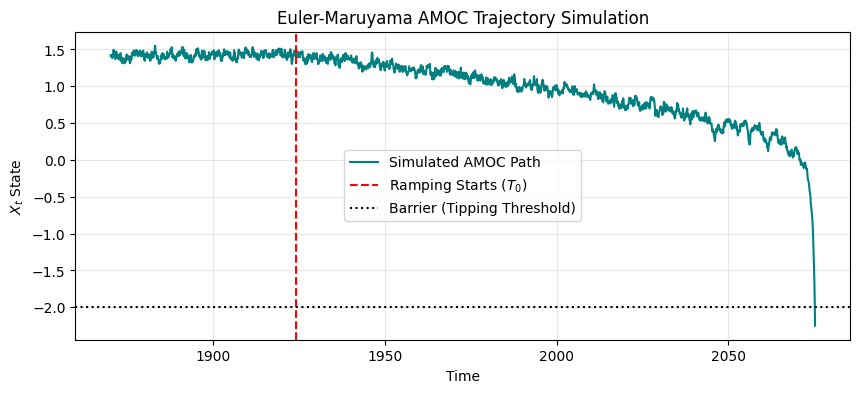

In [258]:
# Run a single trajectory simulation
m=0.0
sim_result = X_traj(sigma=0.1, lambda0=-2.0, tau=140.0, m=0.0, a=1.0, duration_bef_ramping=t0 - 1870, dt=delta_t)

print(f"First Passage (Tipping) Time: {sim_result['FPT'] + 1870:.2f} years")

time_axis = 1870 + np.arange(len(sim_result['X'])) * delta_t 
plt.figure(figsize=(10, 4))
plt.plot(time_axis, sim_result['X'], color='teal', label='Simulated AMOC Path')
plt.axvline(x=t0, color='red', linestyle='--', label='Ramping Starts ($T_0$)')
plt.axhline(y=m - 2.0, color='black', linestyle=':', label='Barrier (Tipping Threshold)') # Note: barrier is m - 2
plt.xlabel('Time')
plt.ylabel('$X_t$ State')
plt.title('Euler-Maruyama AMOC Trajectory Simulation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [259]:
# Many trajectories

np.random.seed(123)  # For reproducibility (set.seed(123))
nsim = 1000          # Number of simulations

# Extract needed parameters from the Stage 1 & Stage 2 models
a = a_est
m = m_est
lambda0 = lambda0_est
alpha0 = alpha_est
sigma2 = sigma2_est
sig = np.sqrt(sigma2)

# Time configuration based on the AMOC dataset
# (Assuming 'df' from the previous notebook cells is your AMOC.data)
time_array = df['time'].values
n = len(time_array)
t0 = 1924.0
T0 = t0 - 1870.0  # Time length of stationary dynamics

# Time-varying sequences for the deterministic model path
# R's pmax(0, x) translates to np.maximum(0, x)
lam_seq = lambda0 * (1.0 - np.maximum(0, (time_array - t0)) / tau_est)
mu_seq = m + np.sqrt(-lam_seq / a)

Delta_t = 1.0 / 12.0  # Time step in years (one measurement per month)
nloop = 20            # Number of simulation steps between observation steps

# -----------------------------------------------------------------------------
# Simulation Loop
# -----------------------------------------------------------------------------
# We'll use a list of arrays to store the results per simulation trace
xx = np.full((n, nsim), np.nan)

for isim in tqdm(range(nsim)):
    # Initial condition is drawn randomly from the stationary distribution
    # rnorm(1, mean=0, sd=sig/sqrt(2*alpha0))
    x0_noise = np.random.normal(0, sig / np.sqrt(2.0 * alpha0))
    x0 = m + np.sqrt(-lambda0 / a) + x0_noise
    
    # Run the continuous trajectory simulation function (defined in previous task)
    # dt = Delta_t / nloop
    sim_data = X_traj(
        sigma=sig, lambda0=lambda0, tau=tau_est, m=m, a=a,
        duration_bef_ramping=t0-1870, X0=x0, dt=Delta_t / nloop, 
        Ymax=nloop * n - 1
    )
    
    xxx_X = sim_data['X']
    nx = len(xxx_X)
    
    # Only keep points at observed monthly times (corresponds to seq(1, nx, nloop))
    xxxx = xxx_X[::nloop]
    nxx = len(xxxx)
    
    # If a trajectory tips early, cap it to match available indices
    if nxx > n:
        xxxx = xxxx[:n]
        nxx = n
        
    # Store sub-sampled trace in our matrix column
    xx[0:nxx, isim] = xxxx

# -----------------------------------------------------------------------------
# Formatting Output Dataset (Mirroring xx.data DataFrame structure)
# -----------------------------------------------------------------------------
# Flatten columns sequentially to match R's default column-major order flattening c(xx)
X_flat = xx.flatten(order='F')

# Create matching repeated metadata vectors
time_flat = np.tile(time_array, nsim)
repetition_flat = np.repeat(np.arange(1, nsim + 1), n)
model_flat = np.tile(m + np.sqrt(-lam_seq / a), nsim)

xx_data = pd.DataFrame({
    'X': X_flat,
    'time': time_flat,
    'repetition': repetition_flat,
    'model': model_flat
})

# Save to CSV for later notebook usage (Alternative to R's .Rdata format)
xx_data.to_csv("SimulatedTraces.csv", index=False)
print(f"Successfully simulated {nsim} traces and saved to 'SimulatedTraces.csv'.")
print(xx_data.head())

100%|██████████| 1000/1000 [01:29<00:00, 11.21it/s]


Successfully simulated 1000 traces and saved to 'SimulatedTraces.csv'.
          X       time  repetition     model
0  0.008541  1870.0833           1  0.247391
1  0.206259  1870.1667           1  0.247391
2 -0.013818  1870.2500           1  0.247391
3  0.334029  1870.3333           1  0.247391
4  0.232640  1870.4167           1  0.247391


### Confidence intervals

 12%|█▏        | 116/1000 [00:02<00:18, 47.51it/s]C:\Users\leole\AppData\Local\Temp\ipykernel_1952\1636550024.py:15: RuntimeWarning: invalid value encountered in sqrt
  alpha_seq  = 2 * np.sqrt(-a * lam_seq)
C:\Users\leole\AppData\Local\Temp\ipykernel_1952\1636550024.py:18: RuntimeWarning: invalid value encountered in sqrt
  mu_seq     = m + np.sqrt(-lam_seq / a)
100%|██████████| 1000/1000 [00:22<00:00, 45.32it/s]


--- Empirical 95% Confidence Intervals ---
alpha   | 95% CI: [  2.4067,   3.9154]
mu      | 95% CI: [  0.1849,   0.2842]
sigma2  | 95% CI: [  0.2636,   0.3382]
tau     | 95% CI: [113.9522, 184.5212]
a       | 95% CI: [  0.5769,   1.4567]
m       | 95% CI: [ -2.1465,  -1.0291]
lambda0 | 95% CI: [ -3.5921,  -1.8925]
tc      | 95% CI: [2037.9522, 2108.5212]


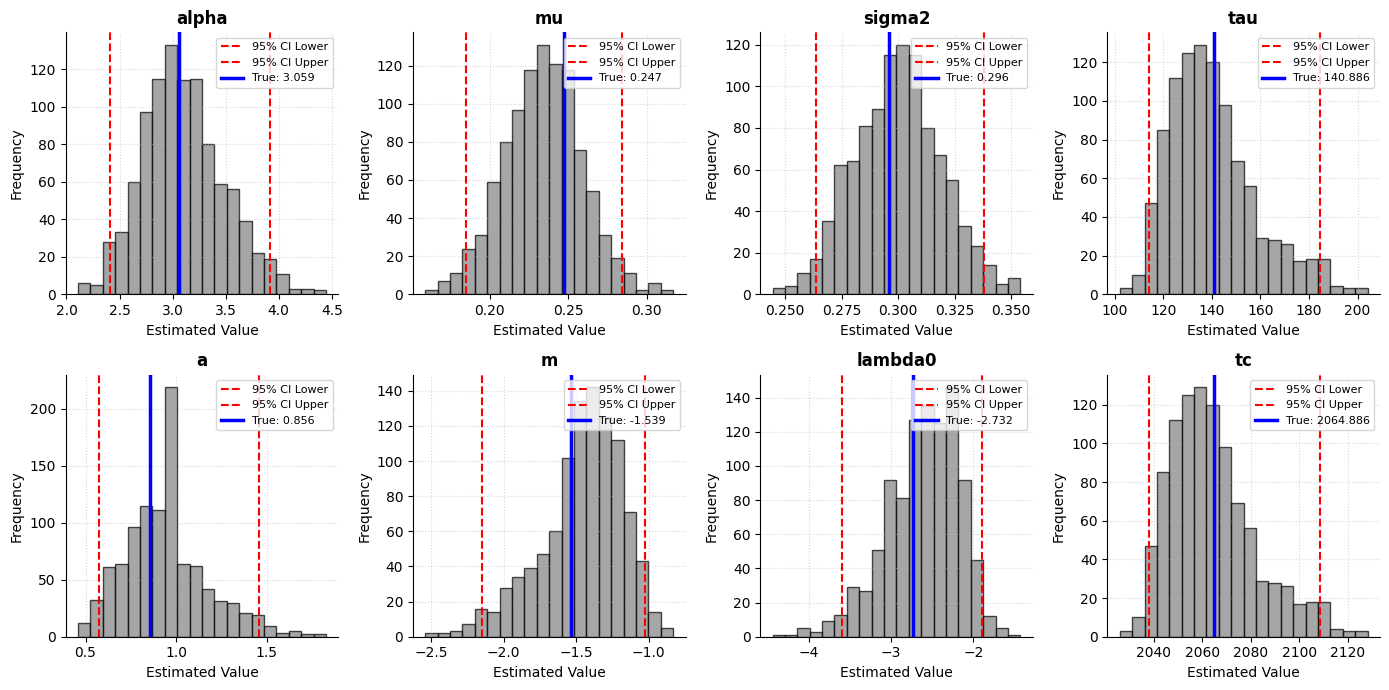

In [260]:
# --- Update 1: Expand parameter names list to include derived parameters ---
param_names = ['alpha', 'mu', 'sigma2', 'tau', 'a', 'm', 'lambda0', 'tc']
estim_matrix = np.zeros((nsim, len(param_names)))

# Pre-calculate true value for tc outside the loop for comparisons
tc_true = tau_est + t0

for isim in tqdm(range(nsim)):
    # Extract trace and drop any early-tipping NaN values for fitting
    trace = xx[:, isim]
    trace_clean = trace[~np.isnan(trace)]
    
    # Separate into stationary phase and non-stationary phase based on simulation structure
    stat_idx = time_array[:len(trace_clean)] < t0
    x_stat_sim = trace_clean[stat_idx]
    x_nonstat_sim = trace_clean[~stat_idx]
    
    try:
        # Stage 1: Stationary OU Fit
        alpha_s, mu_s, sigma2_s = estimate_OU(x_stat_sim, Delta_t)
        
        # Stage 2: Ramping Tipping Fit
        res_tipping_sim = estimate_tipping(
            x_nonstat_sim, Delta_t, 
            alpha0=alpha_s, mu0=mu_s, sigma20=sigma2_s, 
            initial_values=[tau_est, a], pen=0.004
        )
        tau_s, a_s = res_tipping_sim.x
        
        # --- Update 2: Compute the derived parameters for this simulation iteration ---
        m_s = mu_s - alpha_s / (2 * a_s)
        lambda0_s = -(alpha_s**2) / (4 * a_s)
        tc_s = tau_s + t0
        
        # Store all 8 estimates in our matrix row
        estim_matrix[isim, :] = [alpha_s, mu_s, sigma2_s, tau_s, a_s, m_s, lambda0_s, tc_s]
        
    except Exception as e:
        # Fallback to prevent one bad optimization trajectory from stopping the whole loop
        estim_matrix[isim, :] = [np.nan] * len(param_names)

# -----------------------------------------------------------------------------
# 2. Re-shape Estimations into a Long Dataframe (Mirroring R's data.frame setup)
# -----------------------------------------------------------------------------
estim_flat = estim_matrix.flatten(order='F')
type_flat = np.repeat(param_names, nsim)

estim_data = pd.DataFrame({
    'estimate': estim_flat,
    'type': type_flat
}).dropna() # Drop any failed optimization runs

# Define the true comparative parameters matching the parameters used to generate the data
true_values = {
    'alpha': alpha0,
    'mu': mu_seq[0], # stationary mean
    'sigma2': sigma2,
    'tau': tau_est,
    'a': a,
    'm': m,
    'lambda0': lambda0,
    'tc': tc_true
}

# -----------------------------------------------------------------------------
# 3. Plot the Distributions with 95% Confidence Intervals
# -----------------------------------------------------------------------------
# Adjusted col_wrap=4 to nicely space out the 8 plots across a 4x2 grid
g = sns.FacetGrid(estim_data, col="type", sharex=False, sharey=False, col_wrap=4, height=3.5)
g.map(plt.hist, "estimate", bins=20, color="gray", edgecolor="black", alpha=0.7)

print("--- Empirical 95% Confidence Intervals ---")
# Custom mapping loop to append the vertical baselines and 95% CIs
for ax, col_name in zip(g.axes.flatten(), g.col_names):
    # Extract the subset of data for this specific parameter
    param_subset = estim_data[estim_data['type'] == col_name]['estimate']
    
    if len(param_subset) > 0:
        # Calculate the 2.5th and 97.5th percentiles (Empirical 95% CI)
        ci_lower = np.percentile(param_subset, 2.5)
        ci_upper = np.percentile(param_subset, 97.5)
        
        # Plot the 95% Confidence Interval bounds as red dashed lines
        ax.axvline(x=ci_lower, color='red', linestyle='--', linewidth=1.5, label='95% CI Lower')
        ax.axvline(x=ci_upper, color='red', linestyle='--', linewidth=1.5, label='95% CI Upper')
        
        # Print CI values in the console for reference
        print(f"{col_name:7s} | 95% CI: [{ci_lower:8.4f}, {ci_upper:8.4f}]")

    # Plot the True value line
    if col_name in true_values:
        ax.axvline(x=true_values[col_name], color='blue', linestyle='-', linewidth=2.5, 
                   label=f"True: {true_values[col_name]:.3f}")
        
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_title(f"{col_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Estimated Value")
    ax.set_ylabel("Frequency")
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Early Warning Signals

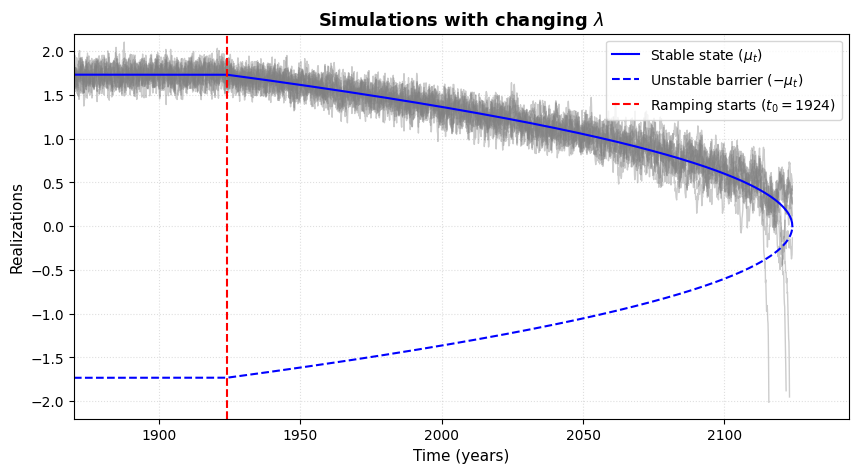

In [ ]:
# -----------------------------------------------------------------------------
# Parameter Setup (Aligned with your calendar year variable definitions)
# -----------------------------------------------------------------------------
tau = 200          # Ramping duration
l0 = -3            # Baseline control parameter lambda
sigm = 0.25        
s2 = sigm**2  

rep = 10           # Number of repetitions
t0 = 1924.0        # Calendar year for start of change (matches your t0)
dt = 0.1           # Observation time step
nloop = 10         

alpha0 = 2 * np.sqrt(-l0)
X0 = np.sqrt(-l0)

# The total simulation spans from the calendar start year (1870) to t0 + tau
start_year = 1870           
Tend = (t0 - start_year) + tau   # Total duration in years from 1870
time_array = start_year + np.arange(0, Tend + dt/2, dt)  # Time axis starting at 1870
n = len(time_array)

# Evolution of lambda over continuous calendar steps
# Stationary phase lasts for (t0 - 1870) years
stationary_steps = int((t0 - start_year) / dt)
stationary_lam = np.repeat(l0, stationary_steps)

# Ramping phase lasts for tau years
ramping_steps = np.arange(0, int(tau / dt) + 1)
ramping_lam = l0 * (1.0 - ramping_steps / (tau / dt))

lt = np.concatenate([stationary_lam, ramping_lam])
if len(lt) > n:
    lt = lt[:n]

mu = np.sqrt(-lt)

# -----------------------------------------------------------------------------
# Run Simulations (Respecting your exact function signature)
# -----------------------------------------------------------------------------
X_matrix = np.full((n, rep), -10.0)

for i in range(rep):
    # Initial condition drawn randomly from stationary distribution
    x0_noise = np.random.normal(0, sigm / np.sqrt(2 * alpha0))
    x0 = X0 + x0_noise
    
    # Execute trajectory simulation matching your exact configuration keys
    # duration_bef_ramping = 1924 - 1870 = 54 years
    xx = X_traj(
        sigma=sigm, lambda0=l0, tau=tau, m=0.0, a=1.0,
        duration_bef_ramping=t0 - start_year, X0=x0, dt=dt / nloop, 
        Ymax=nloop * n - 1
    )
    
    xxx = xx['X'][::nloop]
    nxx = min(n, len(xxx))
    X_matrix[0:nxx, i] = xxx[0:nxx]

# -----------------------------------------------------------------------------
# Reshape Data Frame
# -----------------------------------------------------------------------------
X_flat = X_matrix.flatten(order='F')  
time_flat = np.tile(time_array, rep)
rep_flat = np.repeat(np.arange(1, rep + 1), n)

plotdata = pd.DataFrame({
    'X': X_flat,
    'time': time_flat,
    'rep': rep_flat
})

# Mask out empty/unreached values below threshold
plotdata.loc[plotdata['X'] < -9.9, 'X'] = np.nan

# -----------------------------------------------------------------------------
# Generate Plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 5))

# Plot each simulated trajectory matching your styling setup
for r in range(1, rep + 1):
    sub = plotdata[plotdata['rep'] == r]
    y_vals = np.maximum(sub['X'].values, -2.2)
    plt.plot(sub['time'], y_vals, color='gray', alpha=0.4, linewidth=1)

# Plot stable and unstable boundaries (+mu and -mu) mapped to calendar time
plt.plot(time_array, mu, color='blue', linewidth=1.5, label=r'Stable state ($\mu_t$)')
plt.plot(time_array, -mu, color='blue', linewidth=1.5, linestyle='--', label=r'Unstable barrier ($-\mu_t$)')

plt.xlim(start_year, start_year + Tend + 20)
plt.ylim(-2.2, 2.2)
plt.xlabel("Time (years)", fontsize=11)
plt.ylabel("Realizations", fontsize=11)
plt.title("Simulations with changing $\\lambda$", fontsize=13, fontweight='bold')
plt.axvline(x=t0, color='red', linestyle='--', label=f'Ramping starts ($t_0={int(t0)}$)')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper right')
plt.show()

## Possibility integration

Possibility functions on the model's parameters.

--- Stage 1: Stationary block (alpha, mu, sigma2) ---
Alpha:  3.0592
Mu:     0.2474
Sigma2: 0.2962 (Sigma: 0.5442)
Supremum Log-Likelihood over Omega: 1905.9934

Sanity check - possibility at argmax: 1.0000

--- Stage 2: Non-stationary / tipping block (tau, a) ---
tau (Ramping Time Scale):          140.8806
a (Drift Quadratic Factor):        0.8565
m (Mean Shift Threshold):          -1.5384
lambda_0 (Control Parameter):      -2.7316
tc (Deterministic Critical Time):  2064.8806
Supremum Pseudo-Log-Likelihood:    3461.1464

Sanity check - tipping possibility at argmax: 1.0000

Computing profiles for alpha, mu, sigma...
Computing profiles for tau, a...


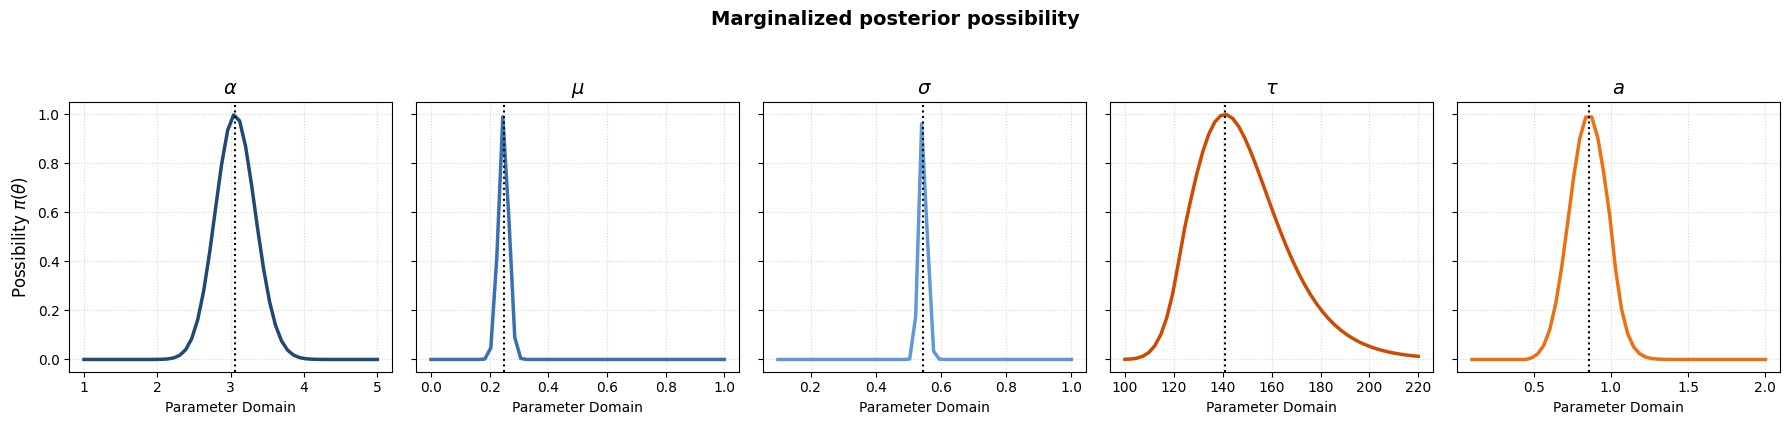

In [262]:

BOUNDS = {
    'alpha': (1.0, 5.0),
    'mu':    (0.0, 1.0),
    'sigma2': (0.01, 1.0),
    'tau':   (100.0, 220.0),
    'a':     (0.1, 2.0),
}


def b(*keys):
    """Convenience: return a list of (lo, hi) tuples for given keys, in order."""
    return [BOUNDS[k] for k in keys]


# =============================================================================
# 1. Stationary block: estimate (alpha, mu, sigma2) via L-BFGS-B over Omega
# =============================================================================
def estimate_OU_bounded(data, delta):
    """
    Finds the supremum of the log-likelihood over the hypercube Omega
    (alpha, mu, sigma2) using L-BFGS-B to respect the bounding constraints.
    Assumes loglikOU_fun returns the NEGATIVE log-likelihood (to be minimized).
    """
    mu_init = np.clip(np.mean(data), *BOUNDS['mu'])
    alpha_init = 3.25
    s2_init = 0.1
    par_init = [alpha_init, mu_init, s2_init]

    def minuslogl(pars):
        try:
            val = loglikOU_fun(pars, data, delta)
            return 1e4 if np.isnan(val) else val
        except Exception:
            return 1e4

    res = minimize(minuslogl, par_init, method='L-BFGS-B',
                    bounds=b('alpha', 'mu', 'sigma2'))

    max_log_lik = -res.fun
    best_pars = res.x
    return best_pars, max_log_lik


def posterior_possibility(pars, data, delta, sup_log_lik_val):
    """
    pi(alpha, mu, sigma) in [0, 1]. `pars` is given in terms of sigma (not
    sigma^2), to match the profiling/plotting convention. Returns 0.0 outside Omega.
    """
    alpha, mu, sigma = pars
    if not (BOUNDS['alpha'][0] <= alpha <= BOUNDS['alpha'][1] and
            BOUNDS['mu'][0]    <= mu    <= BOUNDS['mu'][1] and
            BOUNDS['sigma2'][0] <= sigma**2 <= BOUNDS['sigma2'][1]):
        return 0.0

    pars_converted = [alpha, mu, sigma**2]
    current_log_lik = -loglikOU_fun(pars_converted, data, delta)
    return np.exp(current_log_lik - sup_log_lik_val)


# =============================================================================
# 2. Non-stationary (tipping) block: estimate (tau, a) via L-BFGS-B over Omega
# =============================================================================
def estimate_tipping_bounded(data, delta, alpha0, mu0, sigma20, pen=0.004):
    """
    Finds the supremum of the pseudo-log-likelihood over the hypercube
    (tau, a) using L-BFGS-B. alpha0, mu0, sigma20 are fixed (estimated
    upstream from the stationary block).
    """
    tau_lo, tau_hi = BOUNDS['tau']
    a_lo, a_hi = BOUNDS['a']
    par_init = [(tau_lo + tau_hi) / 2.0, (a_lo + a_hi) / 2.0]

    def minuslogl(pars):
        try:
            val = loglik_fun(pars, data, delta, alpha0, mu0, sigma20, pen)
            return 1e4 if np.isnan(val) else val
        except Exception:
            return 1e4

    res = minimize(minuslogl, par_init, method='L-BFGS-B',
                    bounds=b('tau', 'a'))

    max_pseudo_log_lik = -res.fun
    best_pars = res.x
    return best_pars, max_pseudo_log_lik


def posterior_possibility_tipping(pars, data, delta, alpha0, mu0, sigma20,
                                   sup_log_lik_val, pen=0.004):
    """pi(tau, a) in [0, 1]. Returns 0.0 outside Omega."""
    tau, a = pars
    if not (BOUNDS['tau'][0] <= tau <= BOUNDS['tau'][1] and
            BOUNDS['a'][0]   <= a   <= BOUNDS['a'][1]):
        return 0.0

    current_log_lik = -loglik_fun(pars, data, delta, alpha0, mu0, sigma20, pen)
    return np.exp(current_log_lik - sup_log_lik_val)


# =============================================================================
# 3. Run estimation: stationary block first, then non-stationary block
# =============================================================================
x_stat = df_stat['AMOC2'].values
x_nonstat = df_nonstat['AMOC2'].values

best_pars_omega, sup_log_lik = estimate_OU_bounded(x_stat, delta_t)
alpha_est, mu_est, sigma2_est = best_pars_omega

print("--- Stage 1: Stationary block (alpha, mu, sigma2) ---")
print(f"Alpha:  {alpha_est:.4f}")
print(f"Mu:     {mu_est:.4f}")
print(f"Sigma2: {sigma2_est:.4f} (Sigma: {np.sqrt(sigma2_est):.4f})")
print(f"Supremum Log-Likelihood over Omega: {sup_log_lik:.4f}\n")

possibility_at_argmax = posterior_possibility(
    [alpha_est, mu_est, np.sqrt(sigma2_est)], x_stat, delta_t, sup_log_lik
)
print(f"Sanity check - possibility at argmax: {possibility_at_argmax:.4f}\n")

best_pars_tipping, sup_pseudo_log_lik = estimate_tipping_bounded(
    x_nonstat, delta_t, alpha0=alpha_est, mu0=mu_est, sigma20=sigma2_est, pen=0.004
)
tau_est, a_est = best_pars_tipping
m_est = mu_est - alpha_est / (2 * a_est)
lambda0_est = -(alpha_est**2) / (4 * a_est)
tc = tau_est + t0

print("--- Stage 2: Non-stationary / tipping block (tau, a) ---")
print(f"tau (Ramping Time Scale):          {tau_est:.4f}")
print(f"a (Drift Quadratic Factor):        {a_est:.4f}")
print(f"m (Mean Shift Threshold):          {m_est:.4f}")
print(f"lambda_0 (Control Parameter):      {lambda0_est:.4f}")
print(f"tc (Deterministic Critical Time):  {tc:.4f}")
print(f"Supremum Pseudo-Log-Likelihood:    {sup_pseudo_log_lik:.4f}\n")

possibility_at_argmax_t = posterior_possibility_tipping(
    [tau_est, a_est], x_nonstat, delta_t, alpha_est, mu_est, sigma2_est, sup_pseudo_log_lik
)
print(f"Sanity check - tipping possibility at argmax: {possibility_at_argmax_t:.4f}\n")


# =============================================================================
# 4. Marginalized possibility profiles over each parameter's grid
# =============================================================================
grid_points = 50

intervals = {
    'alpha': np.linspace(*BOUNDS['alpha'], grid_points),
    'mu':    np.linspace(*BOUNDS['mu'], grid_points),
    'sigma': np.linspace(np.sqrt(BOUNDS['sigma2'][0]), np.sqrt(BOUNDS['sigma2'][1]), grid_points),
    'tau':   np.linspace(*BOUNDS['tau'], grid_points),
    'a':     np.linspace(*BOUNDS['a'], grid_points),
}
profiles = {param: np.zeros(grid_points) for param in intervals}

print("Computing profiles for alpha, mu, sigma...")

# Profile for alpha: optimize over (mu, sigma2), both at FULL Omega bounds
for i, val in enumerate(intervals['alpha']):
    def obj(pars, val=val):
        return loglikOU_fun([val, pars[0], pars[1]], x_stat, delta_t)
    res = minimize(obj, [mu_est, sigma2_est], method='L-BFGS-B',
                    bounds=b('mu', 'sigma2'))
    profiles['alpha'][i] = np.exp(-res.fun - sup_log_lik)

# Profile for mu: optimize over (alpha, sigma2)
for i, val in enumerate(intervals['mu']):
    def obj(pars, val=val):
        return loglikOU_fun([pars[0], val, pars[1]], x_stat, delta_t)
    res = minimize(obj, [alpha_est, sigma2_est], method='L-BFGS-B',
                    bounds=b('alpha', 'sigma2'))
    profiles['mu'][i] = np.exp(-res.fun - sup_log_lik)

# Profile for sigma: optimize over (alpha, mu); loglikOU_fun wants sigma^2
for i, val in enumerate(intervals['sigma']):
    def obj(pars, val=val):
        return loglikOU_fun([pars[0], pars[1], val**2], x_stat, delta_t)
    res = minimize(obj, [alpha_est, mu_est], method='L-BFGS-B',
                    bounds=b('alpha', 'mu'))
    profiles['sigma'][i] = np.exp(-res.fun - sup_log_lik)

print("Computing profiles for tau, a...")

# Profile for tau: optimize over a (alpha, mu, sigma2 fixed from stage 1)
for i, val in enumerate(intervals['tau']):
    def obj(pars, val=val):
        return loglik_fun([val, pars[0]], x_nonstat, delta_t, alpha_est, mu_est, sigma2_est)
    res = minimize(obj, [a_est], method='L-BFGS-B', bounds=b('a'))
    profiles['tau'][i] = np.exp(-res.fun - sup_pseudo_log_lik)

# Profile for a: optimize over tau, FULL Omega bound (was wrongly restricted to 100-120)
for i, val in enumerate(intervals['a']):
    def obj(pars, val=val):
        return loglik_fun([pars[0], val], x_nonstat, delta_t, alpha_est, mu_est, sigma2_est)
    res = minimize(obj, [tau_est], method='L-BFGS-B', bounds=b('tau'))
    profiles['a'][i] = np.exp(-res.fun - sup_pseudo_log_lik)


# =============================================================================
# 5. Plot all five marginalized possibility profiles
# =============================================================================
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
colors = ['#204878', '#3870b0', '#6098d8', '#cc4c02', '#ec7014']
param_labels = [r'$\alpha$', r'$\mu$', r'$\sigma$', r'$\tau$', '$a$']
keys = ['alpha', 'mu', 'sigma', 'tau', 'a']
estimates = {'alpha': alpha_est, 'mu': mu_est, 'sigma': np.sqrt(sigma2_est),
             'tau': tau_est, 'a': a_est}

for idx, key in enumerate(keys):
    ax = axes[idx]
    ax.plot(intervals[key], profiles[key], color=colors[idx], linewidth=2.5, label='Profile')
    ax.axvline(estimates[key], color='black', linestyle=':')
    ax.set_title(param_labels[idx], fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Domain')
    ax.grid(True, linestyle=':', alpha=0.5)
    if idx == 0:
        ax.set_ylabel(r'Possibility $\pi(\theta)$', fontsize=12)

plt.suptitle('Marginalized posterior possibility',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [263]:
# =============================================================================
# 1. LA VRAISEMBLANCE CONJOINTE (Joint Negative Log-Likelihood)
# =============================================================================
def joint_neg_loglik(pars, x_stat, x_nonstat, delta):
    """
    Calcule la -log-vraisemblance globale sur toute la trajectoire.
    pars = [alpha, mu, sigma, tau, a]
    """
    alpha, mu, sigma, tau, a = pars
    sigma2 = sigma**2
    
    # ---------------------------------------------------------
    # PHASE 1 : Stationnaire (Ornstein-Uhlenbeck) pour t < t0
    # ---------------------------------------------------------
    Xupp_s, Xlow_s = x_stat[1:], x_stat[:-1]
    n_s = len(x_stat)
    
    gamma2 = sigma2 / (2 * alpha)
    rho = np.exp(-alpha * delta)
    
    m_part_s = Xupp_s - Xlow_s * rho - mu * (1 - rho)
    v_part_s = gamma2 * (1 - rho**2)
    
    # Log-vraisemblance OU (à une constante près)
    ll_ou = - n_s * np.log(v_part_s) - np.sum(m_part_s**2 / v_part_s)
    
    # ---------------------------------------------------------
    # PHASE 2 : Non-Stationnaire (Strang Splitting) pour t >= t0
    # ---------------------------------------------------------
    # Relations déterministes exactes du modèle
    m = mu - alpha / (2 * a)
    lambda0 = -(alpha**2) / (4 * a)
    
    Xupp_ns, Xlow_ns = x_nonstat[1:], x_nonstat[:-1]
    n_ns = len(x_nonstat)
    time_seq = delta * np.arange(1, n_ns)
    
    # Évolution de lambda(t)
    lam_seq = lambda0 * (1 - time_seq / tau)
    
    # Sécurité numérique : si les paramètres proposés par l'optimiseur
    # font basculer lambda en positif avant la fin des données, on rejette.
    if np.any(-a * lam_seq <= 0) or np.any(-lam_seq / a <= 0):
        return 1e10
        
    alpha_seq  = 2 * np.sqrt(-a * lam_seq)
    gamma2_seq = sigma2 / (2 * alpha_seq)
    rho_seq    = np.exp(-alpha_seq * delta)
    mu_seq     = m + np.sqrt(-lam_seq / a)
    
    fh_half_tmp    = a * delta * (Xlow_ns - mu_seq) / 2
    fh_half_tmpupp = a * delta * (Xupp_ns - mu_seq) / 2
    
    fh_half     = (mu_seq * fh_half_tmp + Xlow_ns) / (fh_half_tmp + 1)
    fh_half_inv = (mu_seq * fh_half_tmpupp - Xupp_ns) / (fh_half_tmpupp - 1)
    
    mu_h     = fh_half * rho_seq + mu_seq * (1 - rho_seq)
    m_part_ns= fh_half_inv - mu_h
    var_part_ns = gamma2_seq * (1 - rho_seq**2)
    
    det_Dfh = 1 / (a * delta * (Xupp_ns - mu_seq) / 2 - 1)**2
    
    pen_term = 0.004 * n_ns * (1/a - 1) if a < 1 else 0
    
    ll_ns = - np.sum(np.log(var_part_ns)) - np.sum(m_part_ns**2 / var_part_ns) + \
             2 * np.sum(np.log(det_Dfh)) - pen_term
             
    # La log-vraisemblance totale est la somme des deux phases
    joint_ll = ll_ou + ll_ns
    return -joint_ll  # Retourne l'opposé pour minimisation


# =============================================================================
# 2. LE SUPREMUM GLOBAL SUR L'HYP   ERCUBE (Le Dénominateur)
# =============================================================================
# Définition de l'Hypercube Omega : (alpha, mu, sigma, tau, a)
bounds_5D = [(1.0, 5.0), (0.0, 1), (0.1, 1), (100.0, 220.0), (0.1, 2.0)]

# Initialisation au milieu de l'hypercube
init_5D = [3.25, 0.25, 0.3, 110.0, 2]

print("1. Recherche du Supremum Global sur l'hypercube (5D)...")
res_global = minimize(
    joint_neg_loglik, init_5D, 
    args=(x_stat, x_nonstat, delta_t), 
    method='L-BFGS-B', bounds=bounds_5D
)

sup_loglik_global = -res_global.fun
best_theta = res_global.x
alpha_est, mu_est, sigma_est, tau_est, a_est = best_theta
m_est = mu_est - alpha_est/(2*a_est)
lambda_est = - alpha_est**2 / (4*a_est)
tc_est = tau_est + t0
print(f"alpha = {alpha_est:.2f}")
print(f"mu_est = {mu_est:.2f}")
print(f"sigma_est = {sigma_est:.2f}")
print(f"tau_est = {tau_est:.2f}")
print(f"a_est = {a_est:.2f}")
print(f"m_est = {m_est:.2f}")
print(f"lambda_est = {lambda_est:.2f}")
print(f"tc_est = {tc_est:.2f}")

1. Recherche du Supremum Global sur l'hypercube (5D)...
alpha = 2.98
mu_est = 0.23
sigma_est = 0.53
tau_est = 137.18
a_est = 0.89
m_est = -1.44
lambda_est = -2.49
tc_est = 2061.18


<>:100: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:100: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\leole\AppData\Local\Temp\ipykernel_1952\1482060416.py:100: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.set_ylabel(r'Possibility $\pi(\theta)$', fontsize=12)


Computing marginalized profiles over the 5D joint space...


Alpha Profile:   0%|          | 0/100 [00:00<?, ?it/s]

a Profile: 100%|██████████| 100/100 [00:02<00:00, 34.16it/s]


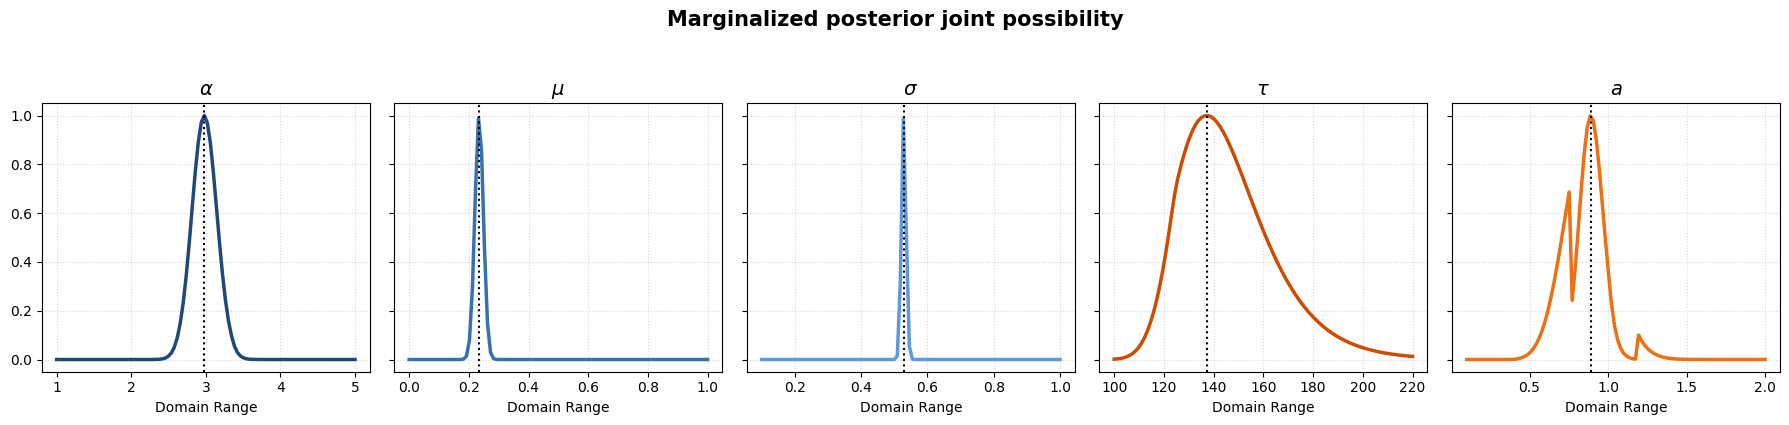

In [ ]:
# =============================================================================
# MARGINALIZED POSSIBILITY PROFILES OVER EACH PARAMETER GRID (JOINT)
# =============================================================================
grid_points = 100

# Use the explicit hypercube limits defined in bounds_5D
intervals = {
    'alpha': np.linspace(bounds_5D[0][0], bounds_5D[0][1], grid_points),
    'mu':    np.linspace(bounds_5D[1][0], bounds_5D[1][1], grid_points),
    'sigma': np.linspace(bounds_5D[2][0], bounds_5D[2][1], grid_points),
    'tau':   np.linspace(bounds_5D[3][0], bounds_5D[3][1], grid_points),
    'a':     np.linspace(bounds_5D[4][0], bounds_5D[4][1], grid_points),
}

profiles = {param: np.zeros(grid_points) for param in intervals}

print("Computing marginalized profiles over the 5D joint space...")

# --- PROFILE FOR ALPHA ---
# Fix alpha, optimize over: [mu, sigma, tau, a]
bounds_alpha = [bounds_5D[1], bounds_5D[2], bounds_5D[3], bounds_5D[4]]
init_alpha = [mu_est, sigma_est, tau_est, a_est]
for i, val in enumerate(tqdm(intervals['alpha'], desc="Alpha Profile")):
    def obj(pars):
        return joint_neg_loglik([val, pars[0], pars[1], pars[2], pars[3]], x_stat, x_nonstat, delta_t)
    res = minimize(obj, init_alpha, method='L-BFGS-B', bounds=bounds_alpha)
    profiles['alpha'][i] = np.exp(-res.fun - sup_loglik_global)

# --- PROFILE FOR MU ---
# Fix mu, optimize over: [alpha, sigma, tau, a]
bounds_mu = [bounds_5D[0], bounds_5D[2], bounds_5D[3], bounds_5D[4]]
init_mu = [alpha_est, sigma_est, tau_est, a_est]
for i, val in enumerate(tqdm(intervals['mu'], desc="Mu Profile")):
    def obj(pars):
        return joint_neg_loglik([pars[0], val, pars[1], pars[2], pars[3]], x_stat, x_nonstat, delta_t)
    res = minimize(obj, init_mu, method='L-BFGS-B', bounds=bounds_mu)
    profiles['mu'][i] = np.exp(-res.fun - sup_loglik_global)

# --- PROFILE FOR SIGMA ---
# Fix sigma, optimize over: [alpha, mu, tau, a]
bounds_sigma = [bounds_5D[0], bounds_5D[1], bounds_5D[3], bounds_5D[4]]
init_sigma = [alpha_est, mu_est, tau_est, a_est]
for i, val in enumerate(tqdm(intervals['sigma'], desc="Sigma Profile")):
    def obj(pars):
        return joint_neg_loglik([pars[0], pars[1], val, pars[2], pars[3]], x_stat, x_nonstat, delta_t)
    res = minimize(obj, init_sigma, method='L-BFGS-B', bounds=bounds_sigma)
    profiles['sigma'][i] = np.exp(-res.fun - sup_loglik_global)

# --- PROFILE FOR TAU ---
# Fix tau, optimize over: [alpha, mu, sigma, a]
bounds_tau = [bounds_5D[0], bounds_5D[1], bounds_5D[2], bounds_5D[4]]
init_tau = [alpha_est, mu_est, sigma_est, a_est]
for i, val in enumerate(tqdm(intervals['tau'], desc="Tau Profile")):
    def obj(pars):
        return joint_neg_loglik([pars[0], pars[1], pars[2], val, pars[3]], x_stat, x_nonstat, delta_t)
    res = minimize(obj, init_tau, method='L-BFGS-B', bounds=bounds_tau)
    profiles['tau'][i] = np.exp(-res.fun - sup_loglik_global)

# --- PROFILE FOR A ---
# Fix a, optimize over: [alpha, mu, sigma, tau]
bounds_a = [bounds_5D[0], bounds_5D[1], bounds_5D[2], bounds_5D[3]]
init_a = [alpha_est, mu_est, sigma_est, tau_est]
for i, val in enumerate(tqdm(intervals['a'], desc="a Profile")):
    def obj(pars):
        return joint_neg_loglik([pars[0], pars[1], pars[2], pars[3], val], x_stat, x_nonstat, delta_t)
    res = minimize(obj, init_a, method='L-BFGS-B', bounds=bounds_a)
    profiles['a'][i] = np.exp(-res.fun - sup_loglik_global)




# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
colors = ['#204878', '#3870b0', '#6098d8', '#cc4c02', '#ec7014']
param_labels = [r'$\alpha$', r'$\mu$', r'$\sigma$', r'$\tau$', '$a$']
keys = ['alpha', 'mu', 'sigma', 'tau', 'a']
estimates = {'alpha': alpha_est, 'mu': mu_est, 'sigma': sigma_est, 'tau': tau_est, 'a': a_est}

for idx, key in enumerate(keys):
    ax = axes[idx]
    ax.plot(intervals[key], profiles[key], color=colors[idx], linewidth=2.5, label=r'$\pi(\theta|X)$')
    ax.axvline(estimates[key], color='black', linestyle=':', label='MLE Global')
    #ax.axhline(0.05, color='red', linestyle='--', alpha=0.4, label=r'$\alpha=0.05$ threshold')
    ax.set_title(param_labels[idx], fontsize=14, fontweight='bold')
    ax.set_xlabel('Domain Range')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.5)
    """if idx == 0:
        ax.set_ylabel(r'Possibility $\pi(\theta)$', fontsize=12)
        ax.legend(loc='upper right')"""

plt.suptitle('Marginalized posterior joint possibility', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()              

## (Probabilistic) Noise-induced tippings

100%|██████████| 5000/5000 [00:35<00:00, 140.52it/s]


Median tipping year : 2051.041666666667
2.5%, 16.5%, 50%, 83.5%, 97.5% quantiles :
[2031.91666667 2042.66666667 2051.04166667 2057.83333333 2061.25      ]

nb of deterministic tipping / 1000 simulations: 382
np of noise tipping / 1000 simulations: 4618
max of noise tip to check whether or not the arbitrary threshold is ok: 2060.1666666666665
Reminder, tc= 2061.178984075092


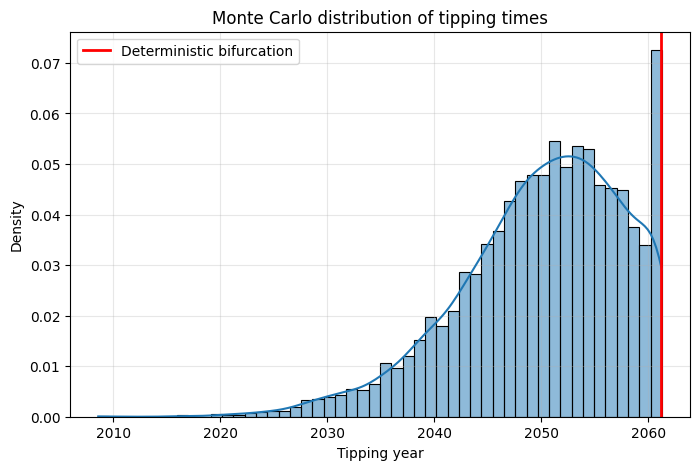

In [265]:
# =============================================================================
# PARAMETERS
# =============================================================================

np.random.seed(123)

nsim = 5000
t0 = 1924
Delta_t = 1/12

alpha = alpha_est
mu = mu_est
sigma = sigma_est
tau = tau_est
a = a_est

m = mu - alpha/(2*a)
lambda0 = -(alpha**2)/(4*a)
tc_est = tau_est + t0

T0 = t0 - 1870

# =============================================================================
# TRAJECTORY FUNCTION (dynamic tipping threshold)
# =============================================================================

def X_traj_new(sigma=0.1, lambda0=-2.0, tau=1000.0, m=0.0, a=1.0, duration_bef_ramping=0.0, X0=np.sqrt(2), dt=0.1, Ymax=1000000):
    Y = 0
    X = X0
    Xtraj = [X]

    barrier = m - np.sqrt(-lambda0 / a)

    while X > barrier and Y < duration_bef_ramping / dt:
        X = S_onestep(sigma=sigma, lambda_val=lambda0, m=m, a=a, X0=X, dt=dt)
        Xtraj.append(X)
        Y += 1

    
    # ramping time begins
    while Y < Ymax:
        time = dt * (Y - duration_bef_ramping / dt)
        current_lambda = lambda0 * (1 - time / tau)

        if current_lambda >= 0:
            break

        barrier = m - np.sqrt(-current_lambda / a)

        X = S_onestep(sigma=sigma, lambda_val=current_lambda, m=m, a=a, X0=X, dt=dt)
        Xtraj.append(X)
        Y += 1

        if X <= barrier:
            break

    return {"FPT": Y * dt + 1870, "X": np.array(Xtraj)} #First Passage Time

# =============================================================================
# MONTE CARLO ESTIMATION OF TIPPING TIMES
# =============================================================================

Ttip = []

noise_tip = []
deterministic_tip = []

for i in tqdm(range(nsim)):
    x0 = m + np.sqrt(-lambda0/a) + np.random.normal(0, sigma/np.sqrt(2*alpha)) # we begin not far from the stable position

    sim = X_traj_new(sigma=sigma, lambda0=lambda0, tau=tau, m=m, a=a, duration_bef_ramping=T0, X0=x0, dt=Delta_t)

    Ttip.append(sim["FPT"]) # includes both deterministic and noise tipping!

    if sim["FPT"] < tc_est - 1: 
        noise_tip.append(sim["FPT"])
    else:
        deterministic_tip.append(sim["FPT"]) #but the noise could delay the deterministic tipping too


Ttip = np.array(Ttip)

print("Median tipping year :", np.median(Ttip))
print("2.5%, 16.5%, 50%, 83.5%, 97.5% quantiles :")
print(np.percentile(Ttip, [2.5, 16.5, 50, 83.5, 97.5]))
print()
print("nb of deterministic tipping / 1000 simulations:", len(deterministic_tip))
print("np of noise tipping / 1000 simulations:", len(noise_tip))
print("max of noise tip to check whether or not the arbitrary threshold is ok:", np.max(np.array(noise_tip)))
print("Reminder, tc=", tc_est)
#P_noise = np.mean(Ttip < tc)
#print("Empirical proba of noise tipping before bifurcation tipping:", P_noise)

# =============================================================================
# HISTOGRAM OF TIPPING TIMES
# =============================================================================

plt.figure(figsize=(8,5))
sns.histplot(Ttip, bins=50, kde=True, stat="density")
plt.axvline(tc_est, color="red", linewidth=2, label="Deterministic bifurcation")
plt.xlabel("Tipping year")
plt.ylabel("Density")
plt.title("Monte Carlo distribution of tipping times")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

C:\Users\leole\AppData\Local\Temp\ipykernel_1952\464451930.py:17: RuntimeWarning: invalid value encountered in sqrt
  barrier = m - np.sqrt(-lambda_barrier/a)


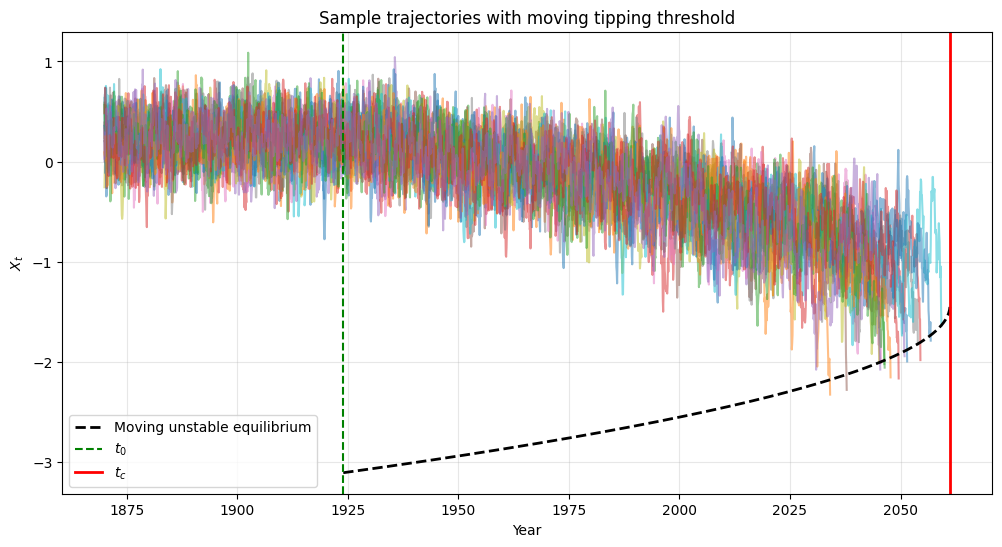

In [266]:
# =============================================================================
# SAMPLE TRAJECTORIES
# =============================================================================

plt.figure(figsize=(12,6))

for i in range(15):
    x0 = m + np.sqrt(-lambda0/a) + np.random.normal(0, sigma/np.sqrt(2*alpha))

    sim = X_traj_new(sigma=sigma, lambda0=lambda0, tau=tau, m=m, a=a, duration_bef_ramping=T0, X0=x0, dt=Delta_t)

    time_axis = 1870 + np.arange(len(sim["X"])) * Delta_t
    plt.plot(time_axis, sim["X"], alpha=0.5)

time_barrier = np.arange(t0, tc, Delta_t)
lambda_barrier = lambda0 * (1 - (time_barrier - t0)/tau)
barrier = m - np.sqrt(-lambda_barrier/a)

plt.plot(time_barrier, barrier, "k--", linewidth=2, label="Moving unstable equilibrium")
plt.axvline(t0, color="green", linestyle="--", label=r"$t_0$")
plt.axvline(t0 + tau, color="red", linewidth=2, label=r"$t_c$")
plt.xlabel("Year")
plt.ylabel("$X_t$")
plt.title("Sample trajectories with moving tipping threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


3.9975558221305344e+17
3.9975558221305056e+17


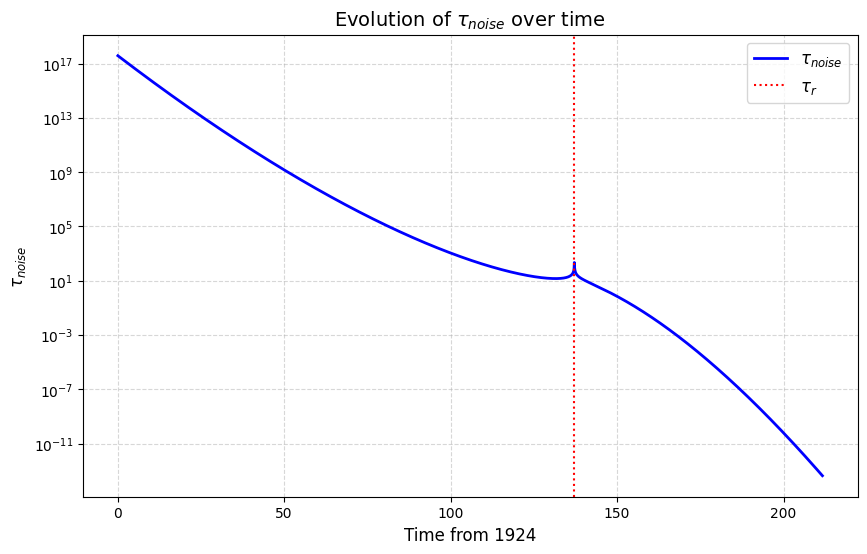

In [267]:
# Potential function and mean noise-induced tipping time formula. 

def U(x, Lambda, A, m):
    return A*(x-m)**3/3 + Lambda * x

def U_2nd(x, A, m):
    return 2*A*(x-m)


def tau_noise(Lambda, sigma, A, m):
    x_minus = m - np.sqrt(np.abs(Lambda)/A)
    x_plus = m + np.sqrt(np.abs(Lambda)/A)
    potential_barrier = U(x_minus, Lambda, A, m) - U(x_plus, Lambda, A, m) 
    numerator = 2*np.pi * np.exp(2*potential_barrier / sigma**2)
    denominator = np.sqrt(U_2nd(x_plus, A, m) * np.abs(U_2nd(x_minus, A, m)))

    return numerator / denominator

# from joint likelihood
alpha_est, mu_est, sigma_est, tau_est, a_est = best_theta
m_est = mu_est - alpha_est/(2*a_est)
lambda_est = - alpha_est**2 / (4*a_est)
tc_est = tau_est + t0

Lambda = lambda_est
A = a_est
m = m_est
formula = (np.pi / np.sqrt(A * np.abs(Lambda))) * np.exp((8 * np.abs(Lambda)**(3/2)) / (3 * np.sqrt(A) * sigma**2))
tau_n = tau_noise(Lambda, sigma, A, m)
print()
print(formula) # both formula and function tau_n coincide so its perfect
print(tau_n) #the waiting time is very long for lambda = lambda 0 because it is almost impossible to have an extreme value of noise reaching the unstable point

delta = 1/12
time_seq = delta * np.arange(1, n)
lam_seq    = lambda0 * (1 - time_seq / tau)

tau_noise_values = [tau_noise(lam, sigma, A, m) for lam in lam_seq]

plt.figure(figsize=(10, 6))
plt.plot(time_seq, tau_noise_values, 'b-', label='$\\tau_{noise}$', linewidth=2)
plt.title('Evolution of $ \\tau_{noise}$ over time', fontsize=14)
plt.axvline(tau_est, color="red", linestyle=":", label="$\\tau_r$")
plt.xlabel('Time from 1924', fontsize=12)
plt.ylabel('$\\tau_{noise}$', fontsize=12)
plt.yscale('log') # Log scale helps view the exponential explosion clearly
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.show()

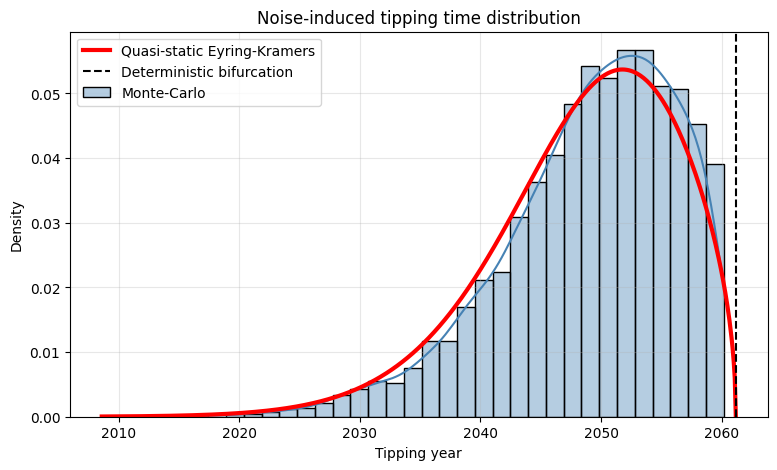

AttributeError: 'list' object has no attribute 'min'

In [ ]:
# =============================================================================
# THEORETICAL DENSITY FROM QUASI-STATIC EYRING-KRAMERS
# =============================================================================

# Time measured from beginning of ramp
t_grid = np.linspace(0, tau_est - 1e-3, 2000)

lambda_grid = lambda0 * (1 - t_grid / tau_est)

tau_grid = np.array([tau_noise(lam, sigma, A, m) for lam in lambda_grid])
hazard_grid = 1 / tau_grid

cumhaz = cumulative_trapezoid(hazard_grid, t_grid, initial=0)

survival = np.exp(-cumhaz)
density = hazard_grid * survival

density /= np.trapezoid(density, t_grid)

density_interp = interp1d(t_grid + t0, density, bounds_error=False, fill_value=0)

hazard_interp = interp1d(t_grid + t0, hazard_grid, bounds_error=False, fill_value=np.nan)


plt.figure(figsize=(9,5))
sns.histplot(noise_tip,stat="density",bins=35,color="steelblue",alpha=0.4,kde=True,label="Monte-Carlo")
years = np.linspace(min(noise_tip), tc_est, 600)
plt.plot(years, density_interp(years), color="red",lw=3,label="Quasi-static Eyring-Kramers")
plt.axvline(tc_est,color="black",linestyle="--",label="Deterministic bifurcation")
plt.xlabel("Tipping year")
plt.ylabel("Density")
plt.title("Noise-induced tipping time distribution")
plt.legend()
plt.grid(alpha=.3)
plt.show()



# =============================================================================
# PROGRESSIVE KOLMOGOROV DISTANCE
# =============================================================================

# Theoretical CDF
t_theory = t_grid + t0         
cdf_theory = 1 - survival       
cdf_interp = interp1d(t_theory,cdf_theory,bounds_error=False,fill_value=(0, cdf_theory[-1]))

# Empirical CDF
n = len(noise_tip)
empirical_cdf = np.arange(1, n+1)/n

# Kolmogorov distance
cutoffs = np.linspace(noise_tip.min(),tc_est-0.2,100)

D = []
for cutoff in cutoffs:

    # observations before cutoff, when we only considers observations before cutoff
    idx = noise_tip <= cutoff

    if np.sum(idx) < 10:
        D.append(np.nan)
        continue

    t_emp = noise_tip[idx]
    F_emp = empirical_cdf[idx]
    F_theory = cdf_interp(t_emp)

    D.append(np.max(np.abs(F_emp - F_theory)))



plt.figure(figsize=(9,5))
plt.plot(cutoffs,D,lw=3)
plt.axvline(tc_est,color="red",linestyle="--",label="Deterministic bifurcation")
plt.xlabel("Cutoff year")
plt.ylabel("Kolmogorov distance")
plt.title("Progressive agreement between Eyring-Kramers and Monte-Carlo")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Outer Probability Measure for noise-induced tippings

C:\Users\leole\AppData\Local\Temp\ipykernel_1952\486875958.py:20: RuntimeWarning: overflow encountered in exp
  * np.exp(2 * barrier / sigma**2)
C:\Users\leole\AppData\Local\Temp\ipykernel_1952\486875958.py:19: RuntimeWarning: overflow encountered in multiply
  2 * np.pi


Possibility = 0.062201
Theta = [  2.97983612   0.23563489   0.52741505 119.56395073   1.05018003]


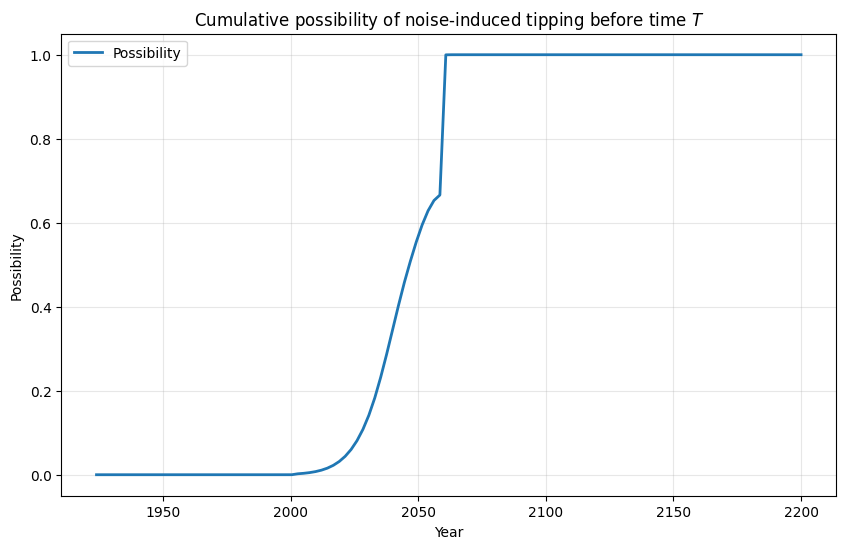

In [ ]:
# =============================================================================
# Vectorized Eyring-Kramers waiting time
# =============================================================================

def tau_noise(Lambda, sigma, A, m):
    """
    Vectorized version.
    Lambda can be a scalar or a NumPy array.
    """

    Lambda = np.asarray(Lambda)

    x_minus = m - np.sqrt(np.abs(Lambda) / A)
    x_plus  = m + np.sqrt(np.abs(Lambda) / A)

    barrier = U(x_minus, Lambda, A, m) - U(x_plus, Lambda, A, m)

    return (
        2 * np.pi
        * np.exp(2 * barrier / sigma**2)
        / np.sqrt(
            U_2nd(x_plus, A, m)
            * np.abs(U_2nd(x_minus, A, m))
        )
    )


# =============================================================================
# Vectorized hazard
# =============================================================================

def hazard_rate(t, theta):

    alpha, mu, sigma, tau, a = theta

    m = mu - alpha / (2 * a)
    lambda0 = -(alpha**2) / (4 * a)

    lam = lambda0 * (1 - t / tau)

    r = np.full_like(lam, np.inf, dtype=float)

    mask = lam < 0

    if np.any(mask):
        r[mask] = 1.0 / tau_noise(lam[mask], sigma, a, m)

    return r


# =============================================================================
# Possibility for one theta
# =============================================================================

def possibility_theta(theta, t_grid):

    # Posterior possibility
    loglik = -joint_neg_loglik(theta, x_stat, x_nonstat, delta_t)
    poss = np.exp(loglik - sup_loglik_global)

    r = hazard_rate(t_grid, theta)

    H = cumulative_trapezoid(r, t_grid, initial=0)

    # Exact CDF of an inhomogeneous Poisson process
    cdf = 1.0 - np.exp(-H[-1])

    return poss * cdf


# =============================================================================
# Global possibility
# =============================================================================

def possibility_noise_before(T, n_grid=500):
    if T <= 0:
        return {"possibility": 0.0, "best_theta": best_theta}

    t_grid = np.linspace(0, T, n_grid)

    def objective(theta):
        return -possibility_theta(theta, t_grid)

    res = minimize(
        objective,
        x0=best_theta,
        method="L-BFGS-B",
        bounds=bounds_5D,
    )

    return {
        "possibility": -res.fun,
        "best_theta": res.x,
        "optimizer": res,
    }


# =============================================================================
# Example
# =============================================================================

T = 100

result = possibility_noise_before(T)

print(f"Possibility = {result['possibility']:.6f}")
print("Theta =", result["best_theta"])

# =============================================================================
# Possibility curve
# =============================================================================

T_values = np.linspace(0, 276, 120)

poss_values = np.array([
    possibility_noise_before(T)["possibility"]
    for T in T_values
])



plt.figure(figsize=(10,6))

plt.plot(1924 + T_values,poss_values,lw=2,label="Possibility")

plt.xlabel("Year")
plt.ylabel("Possibility")
plt.title("Cumulative possibility of noise-induced tipping before time $T$")
plt.grid(alpha=0.3)
plt.legend()

plt.show()





Possibility before T=100: 0.005425
Optimal 4D Theta (alpha, mu, sigma, a) = [2.94604869 0.22825084 0.52851593 0.92040008]


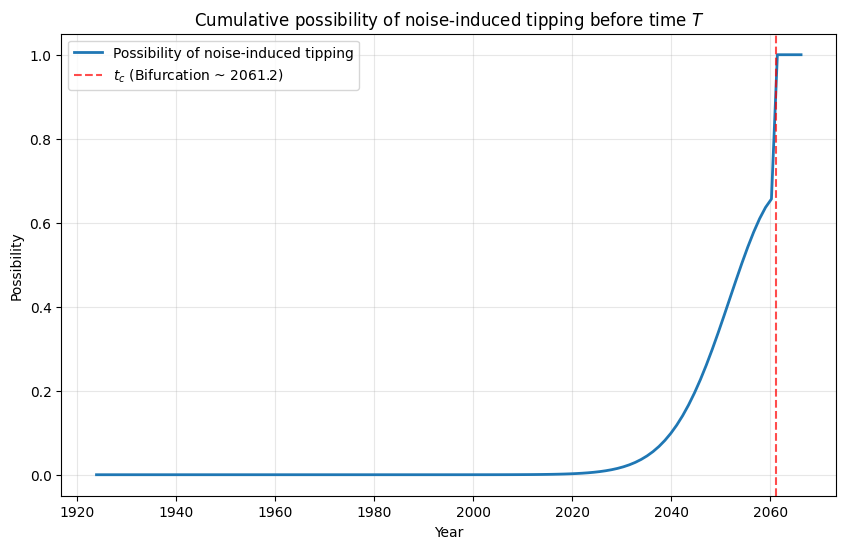

In [ ]:
# =============================================================================
# Vectorized Eyring-Kramers waiting time & Hazard (Unchanged)
# =============================================================================

def tau_noise(Lambda, sigma, A, m):
    Lambda = np.asarray(Lambda)
    x_minus = m - np.sqrt(np.abs(Lambda) / A)
    x_plus  = m + np.sqrt(np.abs(Lambda) / A)

    barrier = U(x_minus, Lambda, A, m) - U(x_plus, Lambda, A, m)

    return (
        2 * np.pi
        * np.exp(2 * barrier / sigma**2)
        / np.sqrt(
            U_2nd(x_plus, A, m)
            * np.abs(U_2nd(x_minus, A, m))
        )
    )

def hazard_rate(t, theta):
    alpha, mu, sigma, tau, a = theta
    m = mu - alpha / (2 * a)
    lambda0 = -(alpha**2) / (4 * a)
    lam = lambda0 * (1 - t / tau)
    
    r = np.full_like(lam, np.inf, dtype=float)
    mask = lam < 0

    if np.any(mask):
        r[mask] = 1.0 / tau_noise(lam[mask], sigma, a, m)
    return r

# =============================================================================
# Possibility for one theta (Now uses 4D optimization and enforces CDF=1 limit)
# =============================================================================

def possibility_theta_4d(theta_4d, T, tau_fixed):
    """
    Evaluates possibility while keeping tau fixed.
    theta_4d = [alpha, mu, sigma, a]
    """
    alpha, mu, sigma, a = theta_4d
    theta = [alpha, mu, sigma, tau_fixed, a]

    # Posterior possibility
    loglik = -joint_neg_loglik(theta, x_stat, x_nonstat, delta_t)
    poss = np.exp(loglik - sup_loglik_global)

    # If T is at or beyond the bifurcation point, tipping is certain (CDF = 1.0)
    if T >= tau_fixed:
        cdf = 1.0
    else:
        # Dynamically generate the grid up to T to save compute
        t_grid = np.linspace(0, T, 500)
        r = hazard_rate(t_grid, theta)
        H = cumulative_trapezoid(r, t_grid, initial=0)
        cdf = 1.0 - np.exp(-H[-1])

    return poss * cdf

# =============================================================================
# Global possibility (Optimizing over 4 parameters)
# =============================================================================

def possibility_noise_before(T, tau_fixed, best_theta_5d, bounds_5d):
    # Extract the 4D baseline components (skipping index 3: tau)
    x0_4D = [best_theta_5d[0], best_theta_5d[1], best_theta_5d[2], best_theta_5d[4]]
    
    if T <= 0:
        return {"possibility": 0.0, "best_theta_4d": x0_4D}

    # Extract 4D bounds (skipping index 3: tau)
    bounds_4D = [bounds_5d[0], bounds_5d[1], bounds_5d[2], bounds_5d[4]]

    def objective(theta_4d):
        return -possibility_theta_4d(theta_4d, T, tau_fixed)

    res = minimize(
        objective,
        x0=x0_4D,
        method="L-BFGS-B",
        bounds=bounds_4D,
    )

    return {
        "possibility": -res.fun,
        "best_theta_4d": res.x,
        "optimizer": res,
    }

# =============================================================================
# Example & Possibility Curve Plotting
# =============================================================================

# Assuming `best_theta` and `bounds_5D` are already in your namespace
tau_est = best_theta[3] 
t0_year = 1924
tc_year = t0_year + tau_est

T_example = 100
result = possibility_noise_before(T_example, tau_est, best_theta, bounds_5D)

print(f"Possibility before T={T_example}: {result['possibility']:.6f}")
print("Optimal 4D Theta (alpha, mu, sigma, a) =", result["best_theta_4d"])

# Draw x-axis until t_c + 5 years
T_max = tau_est + 5 
T_values = np.linspace(0, T_max, 120)

poss_values = np.array([
    possibility_noise_before(T, tau_est, best_theta, bounds_5D)["possibility"]
    for T in T_values
])

plt.figure(figsize=(10,6))
plt.plot(t0_year + T_values, poss_values, lw=2, label="Possibility of noise-induced tipping")
plt.axvline(x=tc_year, color='red', linestyle='--', alpha=0.7, label=f"$t_c$ (Bifurcation ~ {tc_year:.1f})")
plt.xlabel("Year")
plt.ylabel("Possibility")
plt.title("Cumulative possibility of noise-induced tipping before time $T$")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

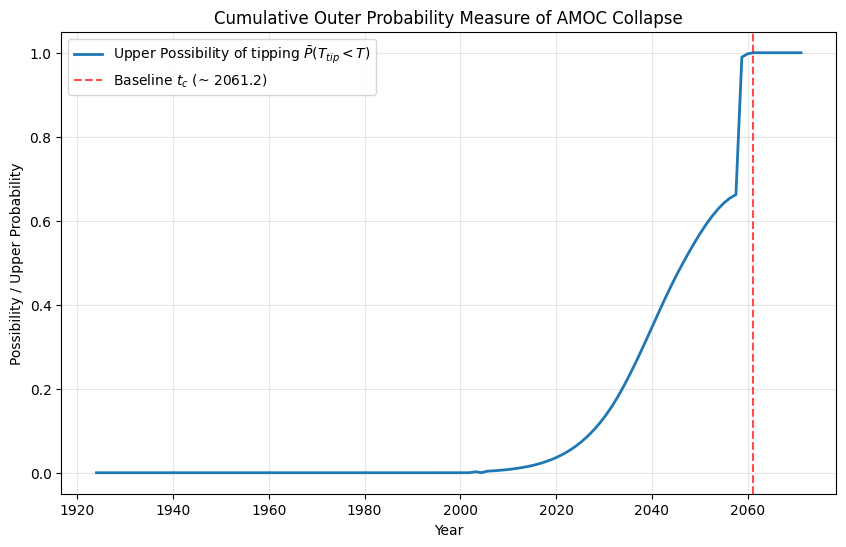

In [ ]:

# =============================================================================
# Vectorized Eyring-Kramers waiting time & Hazard (Unchanged)
# =============================================================================

def tau_noise(Lambda, sigma, A, m):
    Lambda = np.asarray(Lambda)
    x_minus = m - np.sqrt(np.abs(Lambda) / A)
    x_plus  = m + np.sqrt(np.abs(Lambda) / A)

    barrier = U(x_minus, Lambda, A, m) - U(x_plus, Lambda, A, m)

    return (
        2 * np.pi
        * np.exp(2 * barrier / sigma**2)
        / np.sqrt(
            U_2nd(x_plus, A, m)
            * np.abs(U_2nd(x_minus, A, m))
        )
    )

def hazard_rate(t, theta):
    alpha, mu, sigma, tau, a = theta
    m = mu - alpha / (2 * a)
    lambda0 = -(alpha**2) / (4 * a)
    lam = lambda0 * (1 - t / tau)
    
    r = np.full_like(lam, np.inf, dtype=float)
    mask = lam < 0

    if np.any(mask):
        r[mask] = 1.0 / tau_noise(lam[mask], sigma, a, m)
    return r

# =============================================================================
# Possibility for one theta (Now uses full 5D parameter space)
# =============================================================================

def possibility_theta_5d(theta, T):
    """
    Evaluates possibility dynamically calculating t_c(theta) = tau.
    theta = [alpha, mu, sigma, tau, a]
    """
    alpha, mu, sigma, tau, a = theta

    # 1. Epistemic uncertainty (Prior/Likelihood)
    loglik = -joint_neg_loglik(theta, x_stat, x_nonstat, delta_t)
    poss = np.exp(loglik - sup_loglik_global)

    # 2. Aleatoric uncertainty (CDF)
    # --> do we work in relative or absolute time scale??? Tau is defined relatively. 
    #t_c = tau + t0

    if T >= tau:
        # If the target time T is beyond the deterministic tipping point, 
        # tipping has happened almost surely.
        cdf = 1.0
    else:
        # Evaluate noise-induced probability before deterministic tipping
        t_grid = np.linspace(0, T, 500)
        r = hazard_rate(t_grid, theta)
        H = cumulative_trapezoid(r, t_grid, initial=0)
        cdf = 1.0 - np.exp(-H[-1])

    return poss * cdf

# =============================================================================
# Global possibility (Optimizing over all 5 parameters)
# =============================================================================

def possibility_tipping_before(T, best_theta_5d, bounds_5d):
    """
    Finds the supremum of the combined epistemic and aleatoric probability.
    """
    if T <= 0:
        return {"possibility": 0.0, "best_theta_5d": best_theta_5d}

    def objective(theta):
        # We minimize the negative possibility
        return -possibility_theta_5d(theta, T)

    res = minimize(
        objective,
        x0=best_theta_5d,
        method="L-BFGS-B",
        bounds=bounds_5d,
    )

    return {
        "possibility": -res.fun,
        "best_theta_5d": res.x,
        "optimizer": res,
    }

# =============================================================================
# Example & Possibility Curve Plotting
# =============================================================================

# Define time grid (T represents years since t0)
# Let's assume best_theta[3] gives us a baseline estimate for tau
tau_baseline = best_theta[3]
T_max = tau_baseline + 10 
T_values = np.linspace(0, T_max, 120)

poss_values = np.zeros_like(T_values)
optimal_taus = np.zeros_like(T_values) # To track how the optimizer shifts t_c

for i, T in enumerate(T_values):
    result = possibility_tipping_before(T, best_theta, bounds_5D)
    poss_values[i] = result["possibility"]
    optimal_taus[i] = result["best_theta_5d"][3] # Store the tau that maximized possibility

t0_year = 1924
tc_baseline_year = t0_year + tau_baseline

plt.figure(figsize=(10,6))
plt.plot(t0_year + T_values, poss_values, lw=2, label="Upper Possibility of tipping $\\bar{P}(T_{tip} < T)$")
plt.axvline(x=tc_baseline_year, color='red', linestyle='--', alpha=0.7, label=f"Baseline $t_c$ (~ {tc_baseline_year:.1f})")

plt.xlabel("Year")
plt.ylabel("Possibility / Upper Probability")
plt.title("Cumulative Outer Probability Measure of AMOC Collapse")
plt.grid(alpha=0.3)
plt.legend()
plt.show()